# Бинарная классификация: Предсказание статуса курильщика

Используем нейросетевую модель (TensorFlow/Keras) для предсказания вероятности курения на основе медицинских показателей.

In [31]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Проверяем доступность GPU
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Using device: {'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'}")

TensorFlow version: 2.20.0
GPU Available: []
Using device: CPU


## 1. Загрузка и исследование данных

In [32]:
# Загружаем данные
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'\nTrain columns: {train_df.columns.tolist()}')

Train shape: (15000, 24)
Test shape: (10000, 23)

Train columns: ['id', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'smoking']


In [33]:
# Статистика по данным
train_df.describe()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,42.776000,164.764333,64.417333,80.407413,1.033813,1.028093,1.005867,1.005000,119.264067,...,57.320067,113.320133,14.516587,1.017800,0.86640,22.209533,20.899933,26.338667,0.145867,0.370467
std,4330.271354,10.436367,8.503976,11.000541,7.945482,0.316024,0.295498,0.076372,0.070536,11.202995,...,11.517555,18.674356,1.404844,0.169367,0.16628,5.578372,10.091596,19.714344,0.352984,0.482946
min,0.000000,20.000000,140.000000,35.000000,57.400000,0.000000,0.100000,1.000000,1.000000,86.000000,...,28.000000,36.000000,0.900000,1.000000,0.40000,9.000000,2.000000,6.000000,0.000000,0.000000
25%,3749.750000,40.000000,160.000000,55.000000,75.000000,0.800000,0.800000,1.000000,1.000000,110.000000,...,49.000000,100.000000,13.500000,1.000000,0.80000,18.000000,14.000000,15.000000,0.000000,0.000000
50%,7499.500000,40.000000,165.000000,65.000000,80.050000,1.000000,1.000000,1.000000,1.000000,119.000000,...,56.000000,113.000000,14.700000,1.000000,0.90000,21.000000,18.000000,21.000000,0.000000,0.000000
75%,11249.250000,50.000000,170.000000,70.000000,86.000000,1.200000,1.200000,1.000000,1.000000,128.000000,...,65.000000,126.000000,15.600000,1.000000,1.00000,25.000000,24.000000,31.000000,0.000000,1.000000
max,14999.000000,85.000000,190.000000,115.000000,114.000000,9.900000,9.900000,2.000000,2.000000,174.000000,...,106.000000,202.000000,20.000000,4.000000,1.50000,83.000000,139.000000,791.000000,1.000000,1.000000


In [34]:
# Проверяем пропуски
print('Missing values in train:')
print(train_df.isnull().sum())
print(f'\nМissing values in test:')
print(test_df.isnull().sum())

Missing values in train:
id                     0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

Мissing values in test:
id                     0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride

In [35]:
# Баланс классов
print('Target distribution:')
print(train_df['smoking'].value_counts(normalize=True))

Target distribution:
smoking
0.0    0.629533
1.0    0.370467
Name: proportion, dtype: float64


## 2. Подготовка данных

In [36]:
# Разделяем признаки и целевую переменную
feature_cols = [col for col in train_df.columns if col not in ['id', 'smoking']]
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

X = train_df[feature_cols].values
y = train_df['smoking'].values
X_test = test_df[feature_cols].values
test_ids = test_df['id'].values

Feature columns (22): ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']


In [37]:
# Feature Engineering: добавим дополнительные признаки
def create_features(df):
    df = df.copy()
    
    # BMI (Индекс массы тела)
    df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
    
    # Разница зрения между глазами
    df['eyesight_diff'] = abs(df['eyesight(left)'] - df['eyesight(right)'])
    
    # Среднее зрение
    df['eyesight_avg'] = (df['eyesight(left)'] + df['eyesight(right)']) / 2
    
    # Пульсовое давление
    df['pulse_pressure'] = df['systolic'] - df['relaxation']
    
    # Соотношение HDL/LDL
    df['HDL_LDL_ratio'] = df['HDL'] / (df['LDL'] + 1)
    
    # Соотношение триглицеридов к HDL
    df['TG_HDL_ratio'] = df['triglyceride'] / (df['HDL'] + 1)
    
    # AST/ALT ratio (коэффициент де Ритиса)
    df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1)
    
    # Waist to height ratio
    df['waist_height_ratio'] = df['waist(cm)'] / df['height(cm)']
    
    return df

train_fe = create_features(train_df)
test_fe = create_features(test_df)

feature_cols_fe = [col for col in train_fe.columns if col not in ['id', 'smoking']]
print(f'Feature columns with FE ({len(feature_cols_fe)}): {feature_cols_fe}')

X = train_fe[feature_cols_fe].values
y = train_fe['smoking'].values
X_test = test_fe[feature_cols_fe].values

Feature columns with FE (30): ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'BMI', 'eyesight_diff', 'eyesight_avg', 'pulse_pressure', 'HDL_LDL_ratio', 'TG_HDL_ratio', 'AST_ALT_ratio', 'waist_height_ratio']


## 3. Нейросетевая модель

In [38]:
def create_model(input_dim, hidden_dims=[256, 128, 64, 32], dropout=0.3):
    """Создает нейросетевую модель для бинарной классификации"""
    model = keras.Sequential()
    
    # Входной слой
    model.add(layers.Input(shape=(input_dim,)))
    
    # Скрытые слои
    for hidden_dim in hidden_dims:
        model.add(layers.Dense(hidden_dim))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout))
    
    # Выходной слой
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

## 4. Обучение с кросс-валидацией

In [39]:
# Гиперпараметры
N_FOLDS = 5
BATCH_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 1e-3
HIDDEN_DIMS = [256, 128, 64, 32]
DROPOUT = 0.3
PATIENCE = 15  # Early stopping patience

# Для хранения предсказаний
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\n{"="*50}')
    print(f'Fold {fold + 1}/{N_FOLDS}')
    print(f'{"="*50}')
    
    # Разделяем данные
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Инициализируем модель
    model = create_model(
        input_dim=X_train_scaled.shape[1],
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT
    )
    
    # Компилируем модель
    # Используем Adam вместо AdamW для совместимости (AdamW доступен в TF 2.10+)
    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-4)
    except:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    early_stopping = callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )
    
    # Обучение
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # OOF предсказания
    oof_preds[val_idx] = model.predict(X_val_scaled, batch_size=BATCH_SIZE, verbose=0).flatten()
    val_auc = roc_auc_score(y_val, oof_preds[val_idx])
    
    # Test предсказания
    fold_test_preds = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=0).flatten()
    test_preds += fold_test_preds / N_FOLDS
    
    print(f'Fold {fold + 1} Best AUC: {val_auc:.4f}')

# Общий OOF AUC
overall_auc = roc_auc_score(y, oof_preds)
print(f'\n{"="*50}')
print(f'Overall OOF ROC AUC: {overall_auc:.4f}')
print(f'{"="*50}')


Fold 1/5
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.7515 - loss: 0.7000 - val_auc: 0.8459 - val_loss: 0.5513 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8367 - loss: 0.5203 - val_auc: 0.8566 - val_loss: 0.4621 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8554 - loss: 0.4669 - val_auc: 0.8613 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8610 - loss: 0.4479 - val_auc: 0.8647 - val_loss: 0.4377 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8649 - loss: 0.4351 - val_auc: 0.8671 - val_loss: 0.4357 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.8710 - loss: 0.4269 - val_auc: 0.8686 - val_loss: 0.4304 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8719 - loss: 0.4217 - val_auc: 0.8712 - val_loss: 0.4288 - learning_rate: 0.0010
Epo

## 5. Создание submission файла

In [40]:
# Создаем submission
submission = pd.DataFrame({
    'id': test_ids,
    'smoking': test_preds
})

submission.to_csv('submission.csv', index=False)
print('Submission saved!')
print(submission.head(10))

Submission saved!
      id   smoking
0  15000  0.266681
1  15001  0.000655
2  15002  0.044959
3  15003  0.503138
4  15004  0.002915
5  15005  0.458241
6  15006  0.542502
7  15007  0.008094
8  15008  0.618572
9  15009  0.002592


In [41]:
# Проверяем распределение предсказаний
print(f'Prediction statistics:')
print(f'Min: {test_preds.min():.4f}')
print(f'Max: {test_preds.max():.4f}')
print(f'Mean: {test_preds.mean():.4f}')
print(f'Std: {test_preds.std():.4f}')

Prediction statistics:
Min: 0.0000
Max: 0.9868
Mean: 0.3621
Std: 0.3175


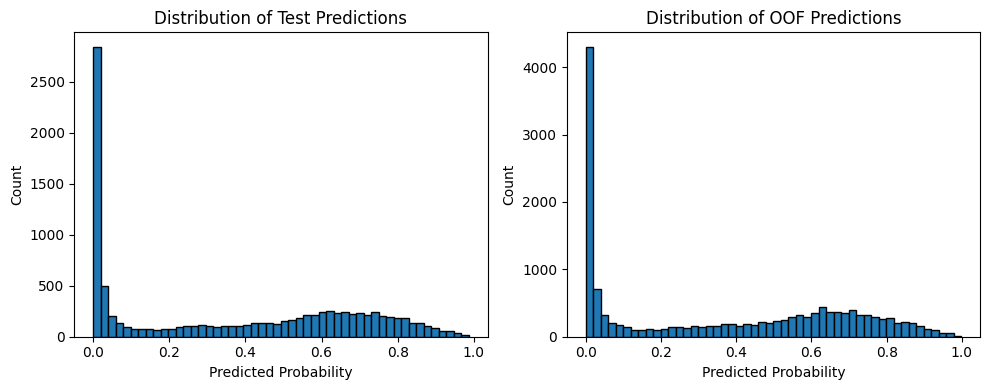

In [42]:
# Гистограмма предсказаний
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(test_preds, bins=50, edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of Test Predictions')

plt.subplot(1, 2, 2)
plt.hist(oof_preds, bins=50, edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of OOF Predictions')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Данные для FT-Transformer
if "train_fe" in globals() and "test_fe" in globals() and "feature_cols" in globals():
    ft_train_df = train_fe
    ft_test_df = test_fe
    ft_feature_cols = feature_cols
else:
    ft_train_df = train_df
    ft_test_df = test_df
    ft_feature_cols = [c for c in train_df.columns if c not in ["id", "smoking"]]

X = ft_train_df[ft_feature_cols].values
Y = ft_train_df["smoking"].values
X_test = ft_test_df[ft_feature_cols].values

FT_CONFIG = {
    "n_folds": 5,
    "batch_size": 128,
    "epochs": 120,
    "learning_rate": 5e-4,
    "patience": 15,
    "d_token": 64,
    "num_heads": 8,
    "num_layers": 3,
    "dropout": 0.1,
}

ft_oof = np.zeros(len(X))
ft_test = np.zeros(len(X_test))

skf = StratifiedKFold(n_splits=FT_CONFIG["n_folds"], shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, Y), 1):
    print(f"\nFT-Transformer Fold {fold}/{FT_CONFIG['n_folds']}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = Y[train_idx], Y[val_idx]

    # Стабилизируем распределения для attention-модели
    scaler = QuantileTransformer(output_distribution="normal", random_state=42)
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    model = build_ft_transformer(
        num_features=X_train.shape[1],
        d_token=FT_CONFIG["d_token"],
        num_heads=FT_CONFIG["num_heads"],
        num_layers=FT_CONFIG["num_layers"],
        dropout=FT_CONFIG["dropout"],
    )

    try:
        optimizer = keras.optimizers.AdamW(
            learning_rate=FT_CONFIG["learning_rate"],
            weight_decay=1e-4,
        )
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=FT_CONFIG["learning_rate"])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")],
    )

    early_stop = callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=FT_CONFIG["patience"],
        restore_best_weights=True,
        verbose=0,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0,
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=FT_CONFIG["epochs"],
        batch_size=FT_CONFIG["batch_size"],
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )

    ft_oof[val_idx] = model.predict(X_val, batch_size=FT_CONFIG["batch_size"], verbose=0).flatten()
    ft_test += model.predict(X_test_scaled, batch_size=FT_CONFIG["batch_size"], verbose=0).flatten() / FT_CONFIG["n_folds"]

    fold_auc = roc_auc_score(y_val, ft_oof[val_idx])
    print(f"Fold {fold} AUC: {fold_auc:.6f}")

    del model
    keras.backend.clear_session()

ft_auc = roc_auc_score(Y, ft_oof)
print(f"\nFT-Transformer OOF AUC: {ft_auc:.6f}")

# Submission
ft_submission = pd.DataFrame({
    "id": ft_test_df["id"].values,
    "smoking": ft_test,
})

ft_submission.to_csv("submission_ft_transformer.csv", index=False)
print("Saved: submission_ft_transformer.csv")
print(ft_submission.head())
